In [19]:
from numpy import count_nonzero,arange,array,dot,asarray,zeros,apply_along_axis,around,sort,shape,savetxt,array_equal,max,argmin,argmax,fill_diagonal,ones,argsort,std,mean,median,diag,random,diff,double,float64
from matplotlib.pyplot import plot,figure,title,legend,xlabel,ylabel,grid,axvline,savefig,imshow,show,scatter,hist,bar,subplot,subplots,text,axhline,stem,xticks,annotate,setp,axes,gca
from math import sqrt,exp,dist
import pandas as pd
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from dtaidistance import dtw
from aeon.distances import msm_distance
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels.api as sm

# Funciones implementadas

In [20]:
#Convertir las filas de una matriz en listas
def conv_to_list(matriz):
    n,m = shape(matriz)
    listas = []
    for i in range(0,n):
        fila_act = matriz[i,:]
        listas.append(fila_act.tolist())
    return listas

#Realizar medias móviles centradas de k días
def media_movil(x_fil, k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = sum(x[i-step:i+step+1])/k
    out = asarray(suav)
    return out

#Realizar medias móviles centradas de k días
def mediana_movil(x_fil, k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = median(x[i-step:i+step+1])
    out = asarray(suav)
    return out

Separar etiquetas de acuerdo al clúster asignado

In [21]:
def sep_clust(etiq_clust,n_clust):
    clust_sep = []
    for k in range(0,n_clust):
        clust_sep.append([])
    n = len(etiq_clust)
    for i in range(0,n):
        clust_act = clust_sep[etiq_clust[i]]
        clust_act.append(i)
    return clust_sep


#Imprimir el nombre de los estados que conforman cada comunidad
#k es el número de clusters
def imp_names(clusters,etiq,dbscan=False):
    n = len(clusters)
    #Crear tantas listas como clusters
    names_clust = []
    for i in range(0,n):
        names_clust.append([])
        clust_act = clusters[i]
        name_act = names_clust[i]
        k = len(clust_act)
        for j in range(0,k):
            name_act.append(etiq[clust_act[j]])
    if dbscan == True:
        for l in range(0,n-1):
            print("Cluster "+str(l))
            print(names_clust[l])
        print("Puntos atípicos:")
        print(names_clust[n-1])
    else:
        for l in range(0,n):
            print("Cluster "+str(l))
            print(names_clust[l])
    return

Calcular la matriz de distancias basándose en la métrica Euclidiana, la métrica MSM o la función DTW

In [22]:
#Matriz para almacenar la distancia euclidiana entre cada par de series de tiempo
def matriz_euclid(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            M[i,j] = dist(series[:,i], series[:,j])
    return M+M.T

#Matriz para almacenar la función DTW entre cada par de series de tiempo
def matriz_dtw(series):
    X = asarray(series, dtype=double)
    M = dtw.distance_matrix_fast(X.T)
    return M 

#Matriz para almacenar la métrica MSM entre las series de tiempo
def matriz_msm(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            x,y = series[:,i].copy(),series[:,j].copy()
            x,y = x.astype(float64), y.astype(float64)
            M[i,j] = msm_distance(x, y)
    return M+M.T

Lista de colores para definir grupos

In [23]:
list_colors=['red','darkorange','blue','royalblue','gold','magenta','green','hotpink','navy','purple','yellow','cyan','brown','olive','lime','silver',
             'gray','crimson','salmon','lawngreen','darkred','crimson','lightgreen','tan','indigo','violet','black','orange','chocolate','steelblue',
             'greenyellow','peru']

# Importar datos de ranking de selecciones de la FIFA

In [24]:
df = pd.read_excel('Ranking_Paises_FIFA.xlsx')
print("Tamaño de la base de datos:")
print(df.shape)
print("Información general de los datos:")
print(df.info())
#Cuántos diferentes valores posee cada variable
print("Cantidad de valores diferentes para cada variable:")
print(df.nunique())

print()
#Verificar si hay valores nulos
print("Valores nulos en cada variable")
print(df.isnull().sum())

Tamaño de la base de datos:
(244, 210)
Información general de los datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Columns: 210 entries, Fecha to Ucrania
dtypes: float64(14), int64(195), object(1)
memory usage: 400.4+ KB
None
Cantidad de valores diferentes para cada variable:
Fecha         244
Afganistán     72
Australia      62
Baréin         79
Bangladesh     58
             ... 
Serbia         43
Suecia         35
Suiza          41
Turquía        47
Ucrania        54
Length: 210, dtype: int64

Valores nulos en cada variable
Fecha          0
Afganistán     0
Australia      0
Baréin         0
Bangladesh     0
              ..
Serbia        40
Suecia         0
Suiza          0
Turquía        0
Ucrania        0
Length: 210, dtype: int64


Filtrar los datos para sólo quedarnos con las selecciones que participan en el mundial de la FIFA 2026

In [25]:
selecciones_mundial_2026 = ['México', 'Sudáfrica', 'República de Corea', 'Chequia', 'Canadá', 'Bosnia y Herzegovina', 'Qatar', 
                            'Suiza', 'Brasil', 'Marruecos', 'Haití', 'Escocia', 'EEUU', 'Paraguay', 'Australia', 
                            'Turquía', 'Alemania', 'Curazao', 'Costa de Marfil', 'Ecuador', 'Países Bajos', 'Japón', 'Suecia', 
                            'Túnez', 'Bélgica', 'Egipto', 'RI de Irán', 'Nueva Zelanda', 'España', 'Cabo Verde', 'Arabia Saudí', 
                            'Uruguay', 'Francia', 'Senegal', 'Irak', 'Noruega', 'Argentina', 'Argelia', 'Austria', 'Jordania', 
                            'Portugal', 'Congo', 'Uzbekistán', 'Colombia', 'Inglaterra', 'Croacia', 'Ghana', 'Panamá']

In [26]:
columnas_filt = ['Fecha']+selecciones_mundial_2026
df1 = df[columnas_filt]
#Borrar filas con valor nulo (sólo nos quedamos con los registros a partir de cierta fecha)
df1 = df1.dropna(axis=0)

KeyError: "['Arabia Saudí'] not in index"

In [ ]:
#Ordenar el dataframe para que se muestren primero las fechas más antiguas y al final las más recientes
df1.sort_values(by='Fecha', inplace=True)

In [ ]:
#Guardar en una lista los nombres de todas las selecciones
nombres_selecciones = df1.columns.tolist()[1:] 
print(nombres_selecciones) 

#Número de selecciones
n_selecciones = len(nombres_selecciones)

#Guardar las fechas correspondientes a los rankings
fechas = df1["Fecha"]

#Pasar los valores del dataframe a una matriz
mat_rankings = df1.values[:,1:]

['México', 'Sudáfrica', 'República de Corea', 'Chequia', 'Canadá', 'Bosnia y Herzegovina', 'Qatar', 'Suiza', 'Brasil', 'Marruecos', 'Haití', 'Escocia', 'EEUU', 'Paraguay', 'Australia', 'Turquía', 'Alemania', 'Curazao', 'Costa de Marfil', 'Ecuador', 'Países Bajos', 'Japón', 'Suecia', 'Túnez', 'Bélgica', 'Egipto', 'RI de Irán', 'Nueva Zelanda', 'España', 'Cabo Verde', 'Arabia Saudí', 'Uruguay', 'Francia', 'Senegal', 'Irak', 'Noruega', 'Argentina', 'Argelia', 'Austria', 'Jordania', 'Portugal', 'Congo', 'Uzbekistán', 'Colombia', 'Inglaterra', 'Croacia', 'Ghana', 'Panamá']


In [ ]:
print(fechas)
#Número de registros
n_fechas = len(fechas)
#Hay aproximadamente un ranking publicado por cada mes desde el 2003, aunque hay algunos meses en los que no se publicó

149    2011-01-12
148    2011-02-02
147    2011-03-09
146    2011-04-13
145    2011-05-18
          ...    
4      2025-11-19
3      2025-12-22
2      2026-01-19
1      2026-04-01
0      2026-06-11
Name: Fecha, Length: 150, dtype: str


<Figure size 800x500 with 0 Axes>

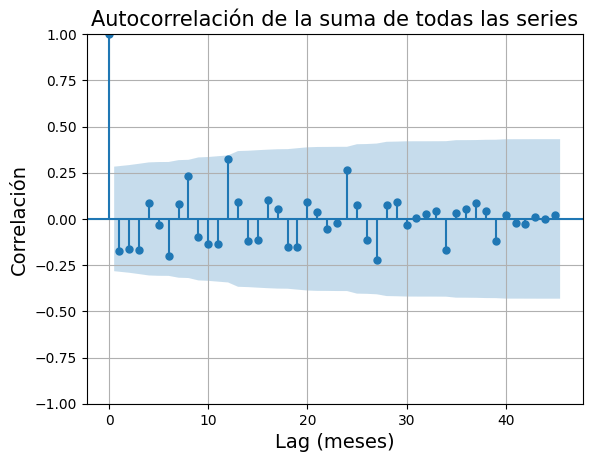

In [ ]:
unique_series = apply_along_axis(sum,0,mat_rankings)
#Correlación cruzada entre las series de tiempo con desfases en un intervalo grande
figure(figsize=(8,5))
number_lags = 45
sm.graphics.tsa.plot_acf(unique_series, lags=number_lags)
#axvline(x=7, linestyle="--", color= 'red')

title("Autocorrelación de la suma de todas las series", fontsize=15)
xlabel("Lag (meses)", fontsize=14)
ylabel("Correlación", fontsize=14)
grid()

**Con base en el gráfico de autocorrelación, se puede concluir que la serie de tiempo que es la suma de todos es estacionaria.**

Text(0.5, 1.0, 'Ranking histórico de las selecciones de fútbol masculino desde 2011')

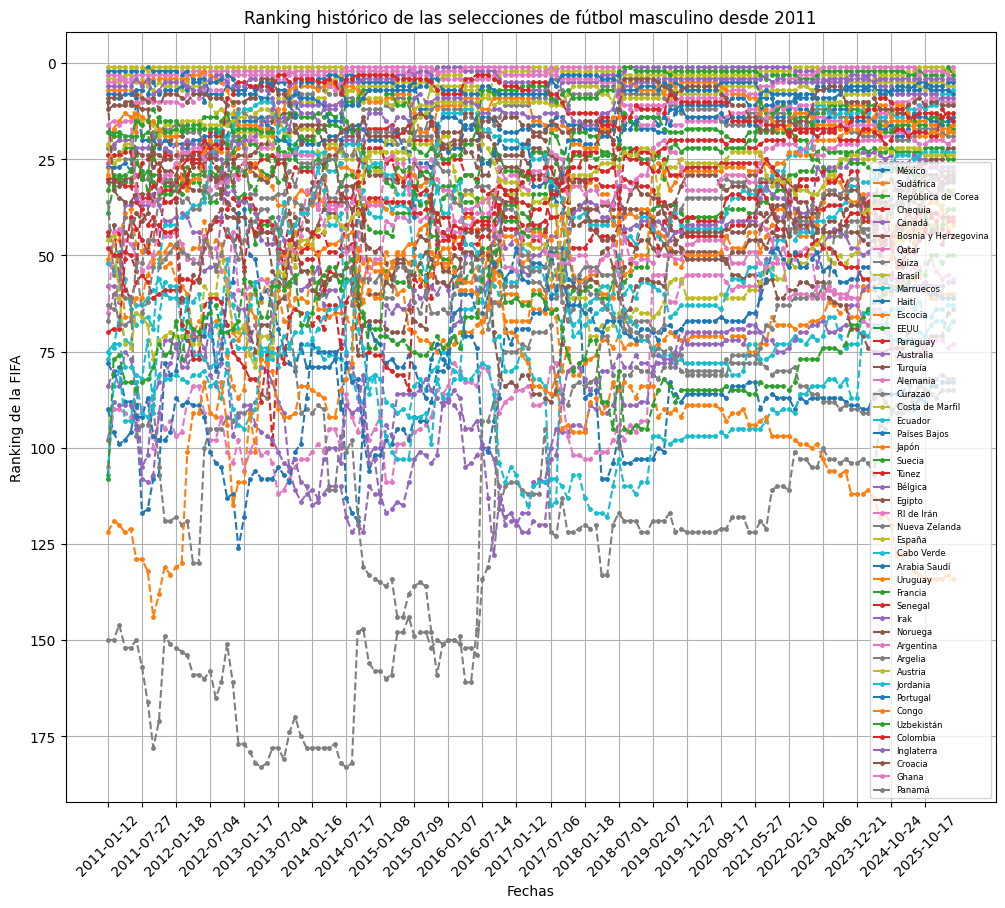

In [ ]:
#Convertir la matriz de series de tiempo a listas
ser_list = conv_to_list(mat_rankings)

figure(figsize = (12,10))
for i in range(0,n_selecciones):
    plot(mat_rankings[:,i], linestyle = "--", marker = "o", markersize=2.5, label=nombres_selecciones[i])
grid()
gca().invert_yaxis()
legend(fontsize=6)

# Seleccionar posiciones para las etiquetas
step = 6
idx = range(0, len(df1["Fecha"]), step)

xticks(idx, df1["Fecha"].iloc[idx], rotation=45)

xlabel("Fechas")
ylabel("Ranking de la FIFA")
title("Ranking histórico de las selecciones de fútbol masculino desde 2011")

## K-means usando la distancia euclidiana

In [ ]:
euc_dist = matriz_euclid(mat_rankings)

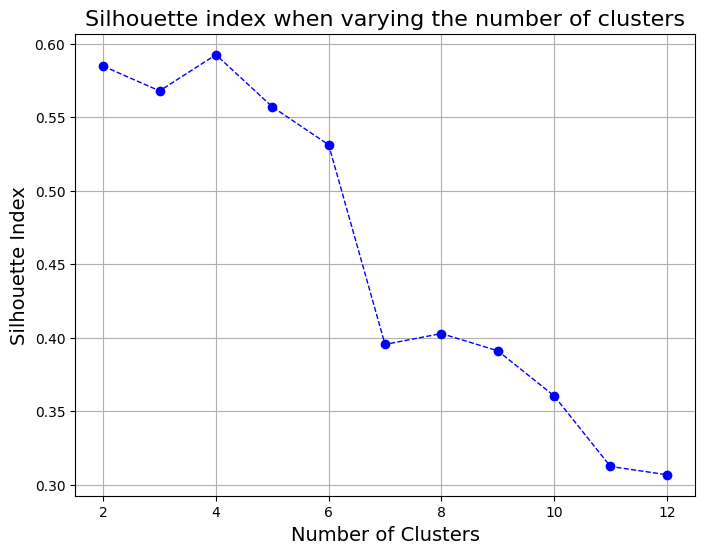

In [ ]:
silhouette_list = []
for i in range(2,int(n_selecciones/4)+1):
    kmeans_euc = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(euc_dist)
    clust_euc = kmeans_euc.labels_
    clust_list_euc = sep_clust(clust_euc,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(euc_dist,clust_euc))

figure(figsize= (8,6))
plot(range(2,int(n_selecciones/4)+1),silhouette_list,linestyle="--",marker="o",markersize=6,linewidth=1.0,color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=4$

In [ ]:
n_clust = 4

kmeans_euc = KMeans(n_clusters=n_clust, random_state=0, n_init='auto').fit(euc_dist)
clust_euc = kmeans_euc.labels_
clust_list_euc = sep_clust(clust_euc,n_clust)
print("Clustering obtenido:")
print(clust_list_euc)
print()
imp_names(clust_list_euc, nombres_selecciones)

Clustering obtenido:
[[2, 3, 5, 9, 11, 13, 14, 15, 18, 19, 21, 22, 23, 25, 26, 33, 35, 37, 38, 46, 47], [1, 4, 6, 10, 29, 30, 34, 39, 41, 42], [0, 7, 8, 12, 16, 20, 24, 28, 31, 32, 36, 40, 43, 44, 45], [17, 27]]

Cluster 0
['República de Corea', 'Chequia', 'Bosnia y Herzegovina', 'Marruecos', 'Escocia', 'Paraguay', 'Australia', 'Turquía', 'Costa de Marfil', 'Ecuador', 'Japón', 'Suecia', 'Túnez', 'Egipto', 'RI de Irán', 'Senegal', 'Noruega', 'Argelia', 'Austria', 'Ghana', 'Panamá']
Cluster 1
['Sudáfrica', 'Canadá', 'Qatar', 'Haití', 'Cabo Verde', 'Arabia Saudí', 'Irak', 'Jordania', 'Congo', 'Uzbekistán']
Cluster 2
['México', 'Suiza', 'Brasil', 'EEUU', 'Alemania', 'Países Bajos', 'Bélgica', 'España', 'Uruguay', 'Francia', 'Argentina', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia']
Cluster 3
['Curazao', 'Nueva Zelanda']


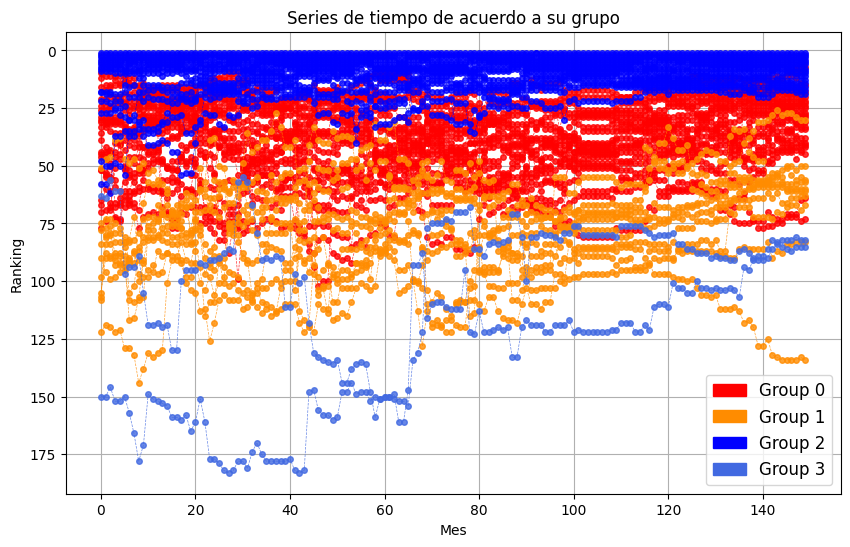

In [ ]:
n1 = shape(mat_rankings)[0]
#Rango de días representados
days_time_serie = arange(0,n1,1)

days_time_serie = arange(0,n1,1)

figure(figsize=(10,6))
grid()
title("Series de tiempo de acuerdo a su grupo")
xlabel("Mes")
ylabel("Ranking")
#Número de comunidades
patches = []
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_clust):
    clust_act = clust_list_euc[k]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie, mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[k], linestyle="--", marker="o", alpha=0.8)
    patch_act = mpatches.Patch(color=list_colors[k], label='Group '+str(k))
    patches.append(patch_act)
gca().invert_yaxis()
legend(handles=patches,prop={'size':12})

**La visualización de todas las series de tiempo juntos no es muy ilustrativa, aunque sí se logran diferenciar algunos comportamientos diferenciados.**

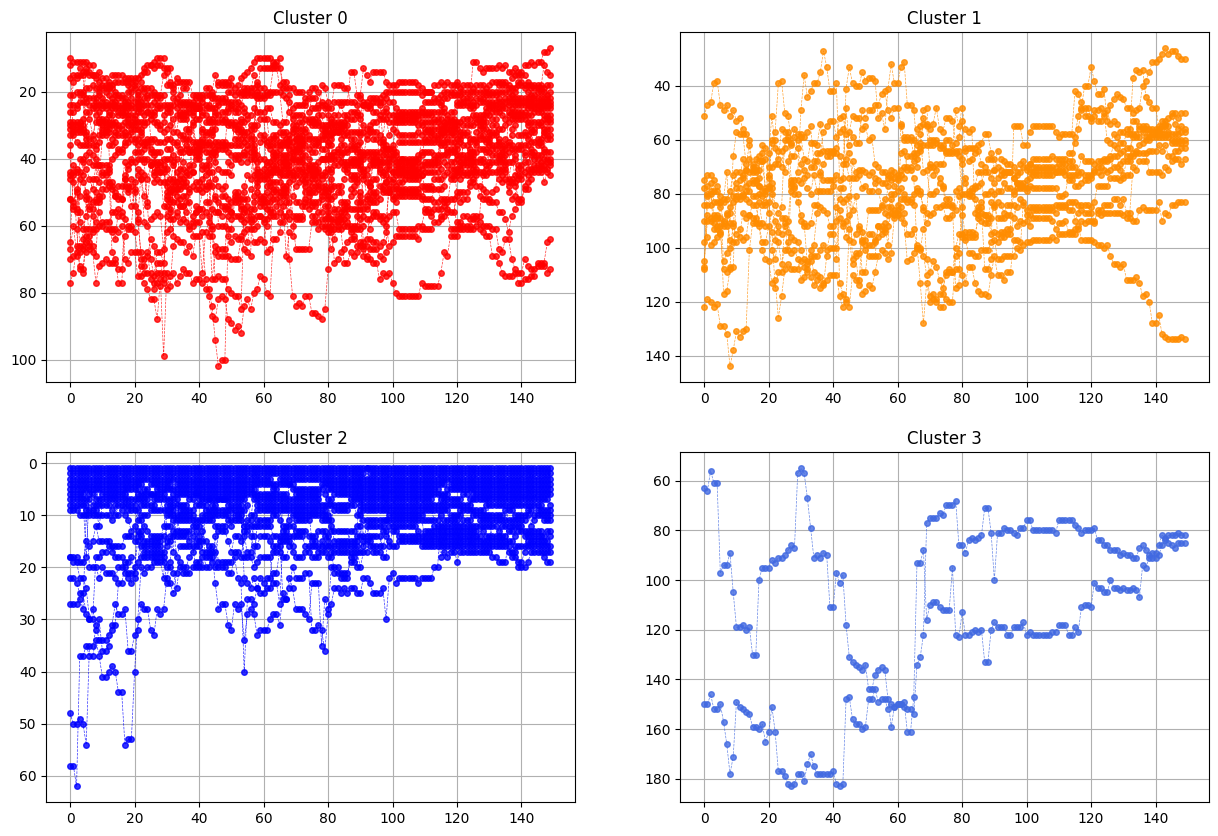

In [ ]:
figure(figsize=(15,10))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    title("Cluster "+str(i))
    clust_act = clust_list_euc[i]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)

## K-Means utilizando la distancia Dynamic Time Warping (DTW)

In [ ]:
dtw_dist = matriz_dtw(mat_rankings)

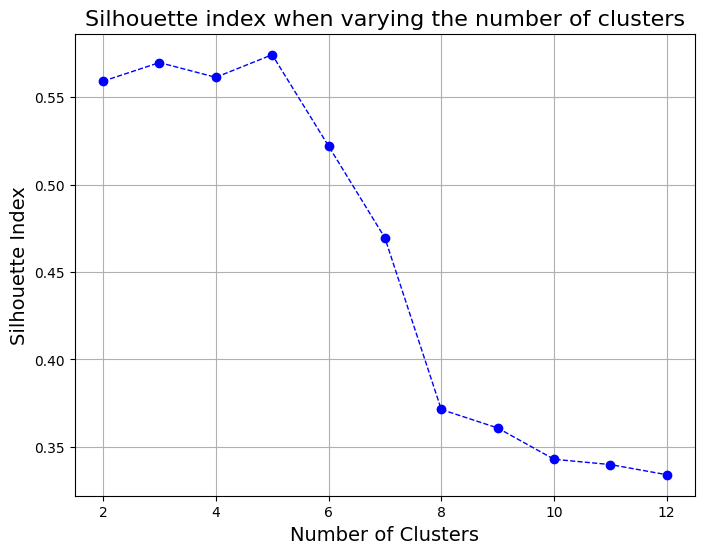

In [ ]:
silhouette_list = []
for i in range(2,int(n_selecciones/4)+1):
    kmeans_dtw = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(dtw_dist)
    clust_dtw = kmeans_dtw.labels_
    clust_list_dtw = sep_clust(clust_dtw,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(dtw_dist,clust_dtw))

figure(figsize= (8,6))
plot(range(2,int(n_selecciones/4)+1),silhouette_list,linestyle="--",marker="o",markersize=6,linewidth=1.0,color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=5$

In [ ]:
n_clust = 5
kmeans_dtw = KMeans(n_clusters=n_clust, random_state=0, n_init='auto').fit(dtw_dist)
clust_dtw = kmeans_dtw.labels_
clust_list_dtw = sep_clust(clust_dtw, n_clust)
print("Clustering obtenido:")
print(clust_list_dtw)
print()
imp_names(clust_list_dtw, nombres_selecciones)

Clustering obtenido:
[[2, 3, 5, 9, 11, 13, 14, 15, 18, 19, 21, 22, 23, 25, 26, 33, 35, 37, 38, 46, 47], [1, 4, 6, 10, 29, 30, 34, 39, 42], [0, 7, 8, 12, 16, 20, 24, 28, 31, 32, 36, 40, 43, 44, 45], [17], [27, 41]]

Cluster 0
['República de Corea', 'Chequia', 'Bosnia y Herzegovina', 'Marruecos', 'Escocia', 'Paraguay', 'Australia', 'Turquía', 'Costa de Marfil', 'Ecuador', 'Japón', 'Suecia', 'Túnez', 'Egipto', 'RI de Irán', 'Senegal', 'Noruega', 'Argelia', 'Austria', 'Ghana', 'Panamá']
Cluster 1
['Sudáfrica', 'Canadá', 'Qatar', 'Haití', 'Cabo Verde', 'Arabia Saudí', 'Irak', 'Jordania', 'Uzbekistán']
Cluster 2
['México', 'Suiza', 'Brasil', 'EEUU', 'Alemania', 'Países Bajos', 'Bélgica', 'España', 'Uruguay', 'Francia', 'Argentina', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia']
Cluster 3
['Curazao']
Cluster 4
['Nueva Zelanda', 'Congo']


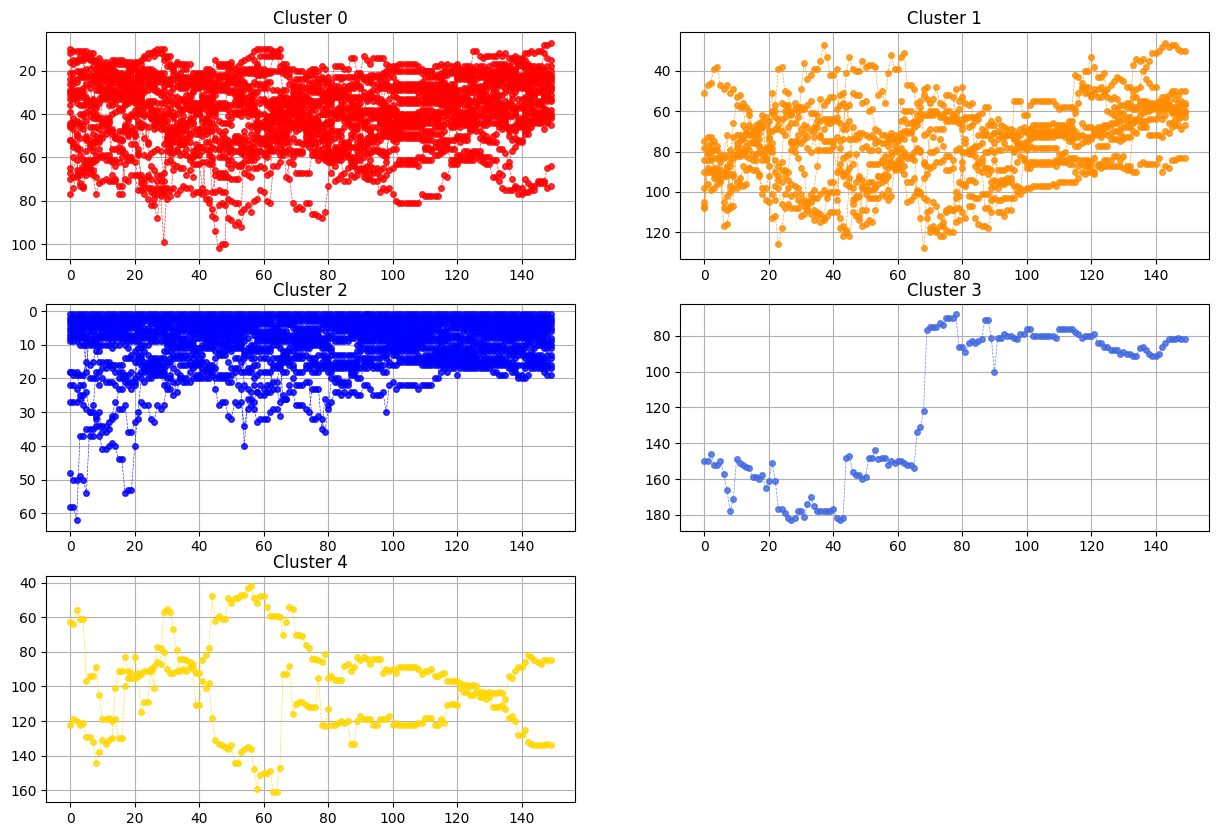

In [ ]:
figure(figsize=(15,10))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    title("Cluster "+str(i))
    clust_act = clust_list_dtw[i]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)

## K-Means utilizando la distancia Move–split–merge (MSM)

In [ ]:
msm_dist = matriz_msm(mat_rankings)

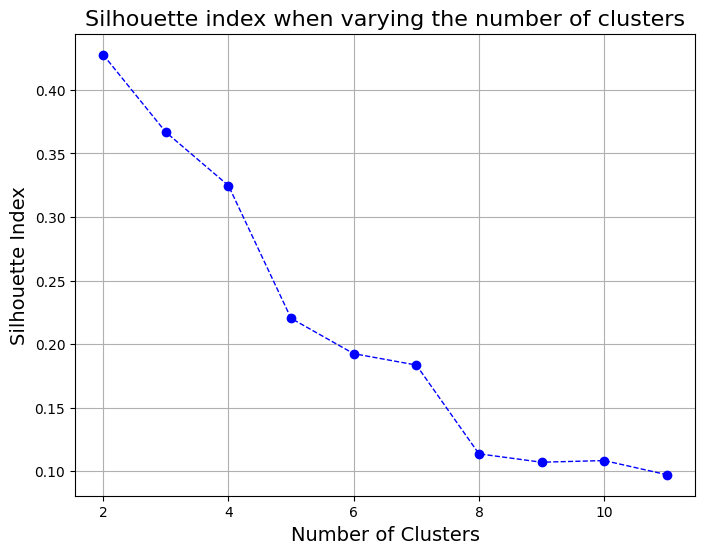

In [ ]:
silhouette_list = []
for i in range(2,int(n_selecciones/4)):
    kmeans_msm = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(msm_dist)
    clust_msm = kmeans_msm.labels_
    clust_list_msm = sep_clust(clust_msm,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(msm_dist,clust_msm))

figure(figsize = (8,6))
plot(range(2,int(n_selecciones/4)), silhouette_list, linestyle="--", marker="o", markersize=6, linewidth=1.0, color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=4$

In [ ]:
n_clust = 4

kmeans_msm = KMeans(n_clusters=n_clust, random_state=0, n_init='auto').fit(msm_dist)
clust_msm = kmeans_msm.labels_
clust_list_msm = sep_clust(clust_msm, n_clust)
print("Clustering obtenido:")
print(clust_list_msm)
print()
imp_names(clust_list_msm, nombres_selecciones)

Clustering obtenido:
[[2, 3, 5, 9, 11, 13, 14, 15, 18, 19, 21, 22, 23, 25, 26, 33, 35, 37, 38, 46, 47], [1, 4, 6, 29, 30, 34, 39, 42], [0, 7, 8, 12, 16, 20, 24, 28, 31, 32, 36, 40, 43, 44, 45], [10, 17, 27, 41]]

Cluster 0
['República de Corea', 'Chequia', 'Bosnia y Herzegovina', 'Marruecos', 'Escocia', 'Paraguay', 'Australia', 'Turquía', 'Costa de Marfil', 'Ecuador', 'Japón', 'Suecia', 'Túnez', 'Egipto', 'RI de Irán', 'Senegal', 'Noruega', 'Argelia', 'Austria', 'Ghana', 'Panamá']
Cluster 1
['Sudáfrica', 'Canadá', 'Qatar', 'Cabo Verde', 'Arabia Saudí', 'Irak', 'Jordania', 'Uzbekistán']
Cluster 2
['México', 'Suiza', 'Brasil', 'EEUU', 'Alemania', 'Países Bajos', 'Bélgica', 'España', 'Uruguay', 'Francia', 'Argentina', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia']
Cluster 3
['Haití', 'Curazao', 'Nueva Zelanda', 'Congo']


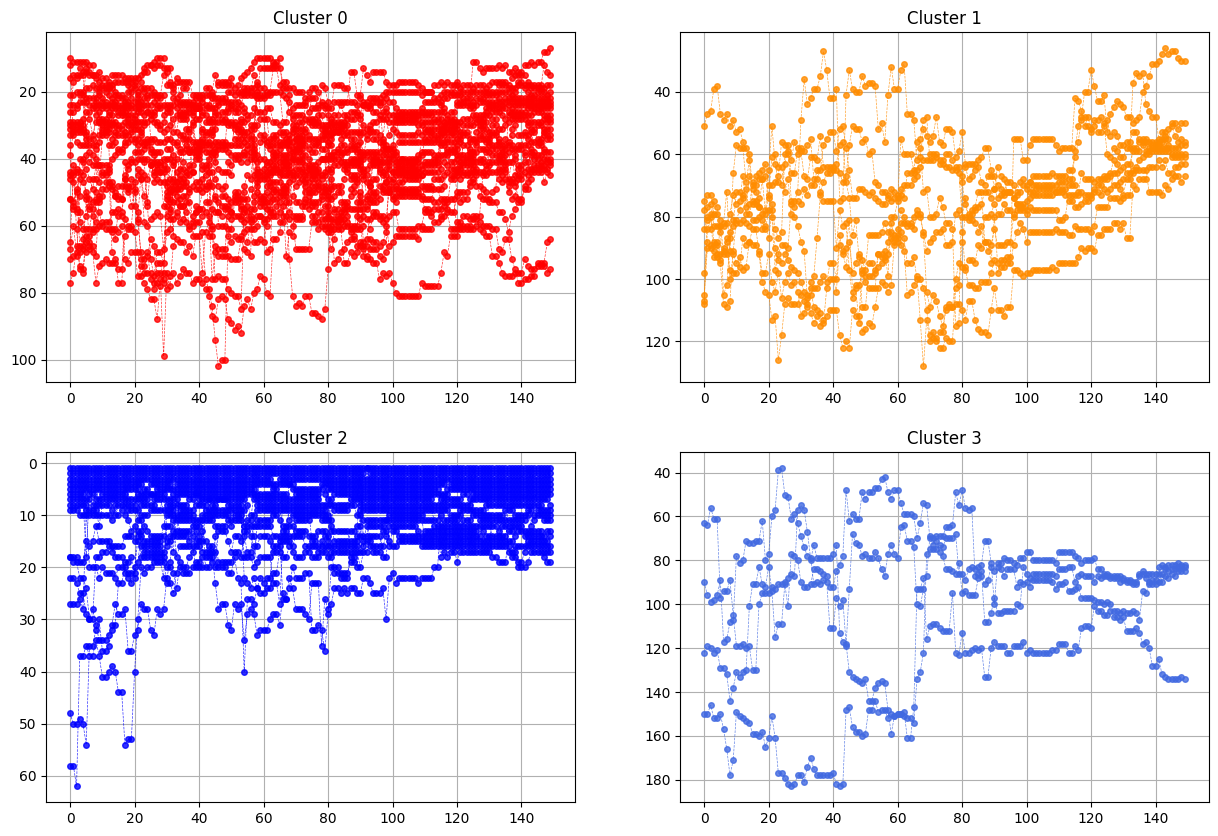

In [ ]:
figure(figsize=(15,10))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    title("Cluster "+str(i))
    clust_act = clust_list_msm[i]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)

# DBSCAN usando la distancia euclidiana

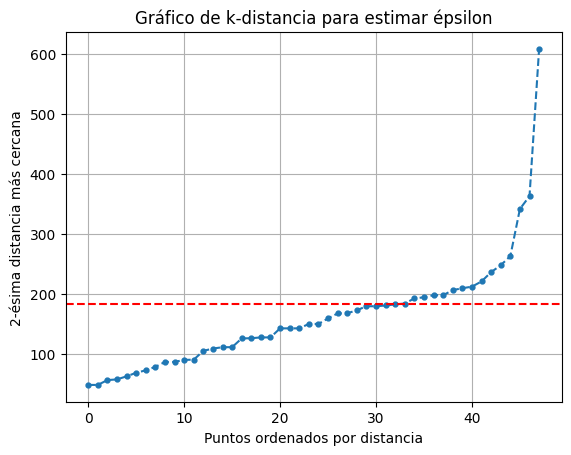

In [ ]:
#la dimensión de las series de tiempo es 1, porque su única variable es el número de casos registrados,
#la cual evoluciona en el tiempo
#min_pts >= 2 
min_pts = 2
neighbors = NearestNeighbors(n_neighbors=min_pts, metric='precomputed')
neighbors_fit = neighbors.fit(euc_dist)
distances, indices = neighbors_fit.kneighbors(euc_dist)

#Ordenar las distancias y graficar
distances = sort(distances[:, min_pts - 1], axis=0)
plot(distances, linestyle="--", marker="o", markersize=3.5)
title('Gráfico de k-distancia para estimar épsilon')
xlabel('Puntos ordenados por distancia')
ylabel(f'{min_pts}-ésima distancia más cercana')
axhline(y=distances[-15], color="red", linestyle="--")
grid()

In [ ]:
#Con base en la gráfica seleccionamos el valor de épsilon
eps_value = distances[-15]

In [ ]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_pts, metric='precomputed')
dbscan.fit(euc_dist)
#Etiquetas de los clústeres
clust_euc_dbscan = dbscan.labels_
#Número de clústers (incluyendo los de etiqueta -1 que son puntos atípicos)
n_clust = len(set(clust_euc_dbscan))
clust_list_euc = sep_clust(clust_euc_dbscan, n_clust)

print("Clustering obtenido:")
print(clust_list_euc)
print()
imp_names(clust_list_euc, nombres_selecciones, dbscan=True)

Clustering obtenido:
[[0, 7, 8, 12, 16, 20, 22, 24, 28, 31, 32, 36, 40, 43, 44, 45], [1, 42], [2, 11, 13, 14, 15, 21, 23, 25, 26, 33, 38], [3, 18, 37], [5, 46], [4, 6, 9, 10, 17, 19, 27, 29, 30, 34, 35, 39, 41, 47]]

Cluster 0
['México', 'Suiza', 'Brasil', 'EEUU', 'Alemania', 'Países Bajos', 'Suecia', 'Bélgica', 'España', 'Uruguay', 'Francia', 'Argentina', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia']
Cluster 1
['Sudáfrica', 'Uzbekistán']
Cluster 2
['República de Corea', 'Escocia', 'Paraguay', 'Australia', 'Turquía', 'Japón', 'Túnez', 'Egipto', 'RI de Irán', 'Senegal', 'Austria']
Cluster 3
['Chequia', 'Costa de Marfil', 'Argelia']
Cluster 4
['Bosnia y Herzegovina', 'Ghana']
Puntos atípicos:
['Canadá', 'Qatar', 'Marruecos', 'Haití', 'Curazao', 'Ecuador', 'Nueva Zelanda', 'Cabo Verde', 'Arabia Saudí', 'Irak', 'Noruega', 'Jordania', 'Congo', 'Panamá']


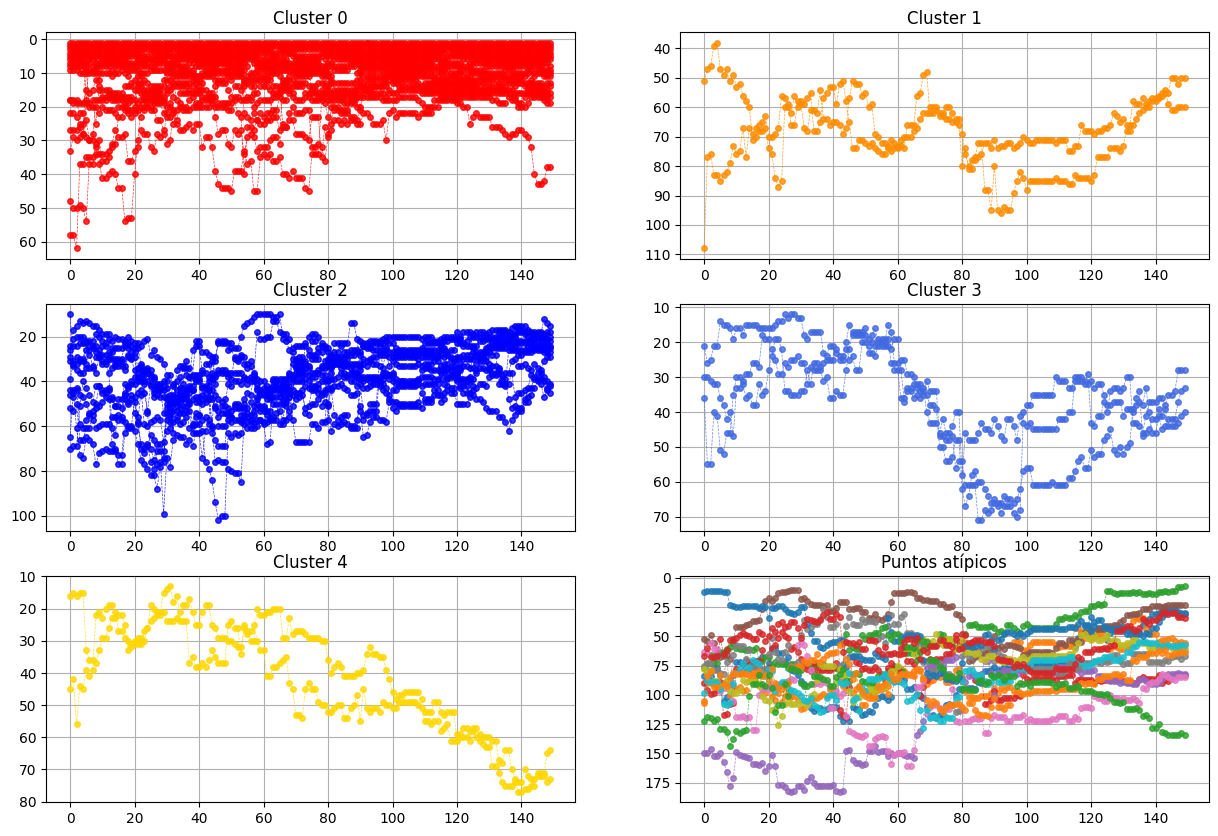

In [ ]:
figure(figsize=(15,10))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    clust_act = clust_list_euc[i]
    len_act = len(clust_act)
    if i != n_clust-1:
        title("Cluster "+str(i))
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)
    else:
        title("Puntos atípicos")
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, linestyle="--", marker="o", alpha=0.8)

# DBSCAN usando la función DTW

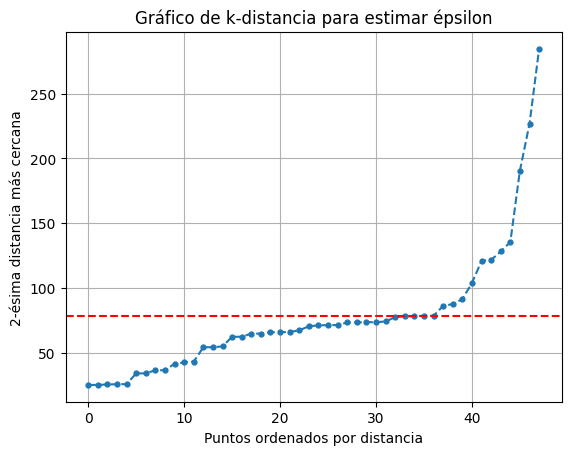

In [ ]:
#la dimensión de las series de tiempo es 1, porque su única variable es el número de casos registrados,
#la cual evoluciona en el tiempo
#min_pts >= 2 
min_pts = 2
neighbors = NearestNeighbors(n_neighbors=min_pts, metric='precomputed')
neighbors_fit = neighbors.fit(dtw_dist)
distances, indices = neighbors_fit.kneighbors(dtw_dist)

#Ordenar las distancias y graficar
distances = sort(distances[:, min_pts - 1], axis=0)
plot(distances, linestyle="--", marker="o", markersize=3.5)
title('Gráfico de k-distancia para estimar épsilon')
xlabel('Puntos ordenados por distancia')
ylabel(f'{min_pts}-ésima distancia más cercana')
axhline(y=distances[-15], color="red", linestyle="--")
grid()


In [ ]:
#Con base en la gráfica seleccionamos el valor de épsilon
eps_value = distances[-15]

In [ ]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_pts, metric='precomputed')
dbscan.fit(dtw_dist)
#Etiquetas de los clústeres
clust_dtw_dbscan = dbscan.labels_
#Número de clústers (incluyendo los de etiqueta -1 que son puntos atípicos)
n_clust = len(set(clust_dtw_dbscan))
clust_list_dtw = sep_clust(clust_dtw_dbscan, n_clust)

print("Clustering obtenido:")
print(clust_list_dtw)
print()
imp_names(clust_list_dtw, nombres_selecciones, dbscan=True)

Clustering obtenido:
[[0, 7, 8, 12, 16, 20, 24, 28, 31, 32, 36, 40, 43, 44, 45], [2, 3, 9, 13, 14, 15, 18, 19, 21, 22, 23, 26, 33, 35, 37, 38], [5, 46], [34, 39], [1, 4, 6, 10, 11, 17, 25, 27, 29, 30, 41, 42, 47]]

Cluster 0
['México', 'Suiza', 'Brasil', 'EEUU', 'Alemania', 'Países Bajos', 'Bélgica', 'España', 'Uruguay', 'Francia', 'Argentina', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia']
Cluster 1
['República de Corea', 'Chequia', 'Marruecos', 'Paraguay', 'Australia', 'Turquía', 'Costa de Marfil', 'Ecuador', 'Japón', 'Suecia', 'Túnez', 'RI de Irán', 'Senegal', 'Noruega', 'Argelia', 'Austria']
Cluster 2
['Bosnia y Herzegovina', 'Ghana']
Cluster 3
['Irak', 'Jordania']
Puntos atípicos:
['Sudáfrica', 'Canadá', 'Qatar', 'Haití', 'Escocia', 'Curazao', 'Egipto', 'Nueva Zelanda', 'Cabo Verde', 'Arabia Saudí', 'Congo', 'Uzbekistán', 'Panamá']


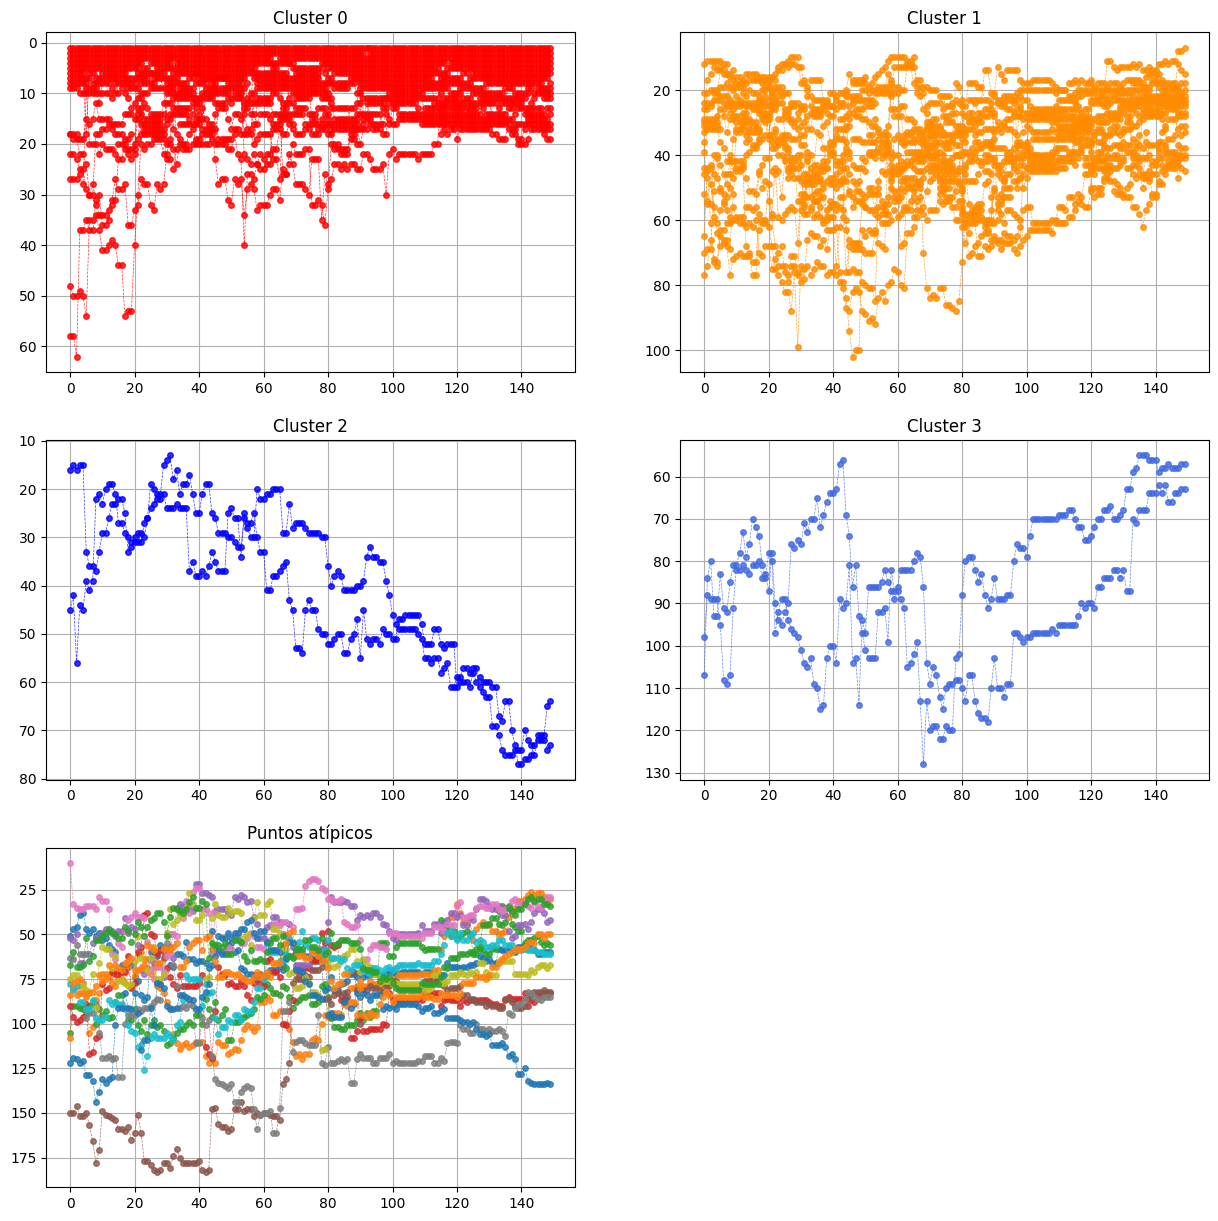

In [ ]:
figure(figsize=(15,15))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    clust_act = clust_list_dtw[i]
    len_act = len(clust_act)
    if i != n_clust-1:
        title("Cluster "+str(i))
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)
    else:
        title("Puntos atípicos")
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, linestyle="--", marker="o", alpha=0.8)

# DBSCAN usando la función MSM

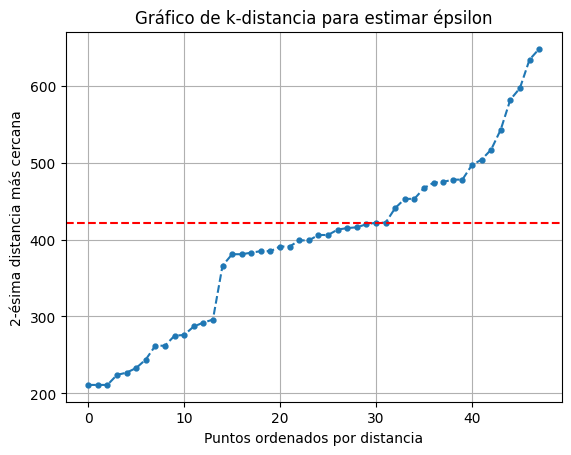

In [ ]:
#la dimensión de las series de tiempo es 1, porque su única variable es el número de casos registrados,
#la cual evoluciona en el tiempo
#min_pts >= 2 
min_pts = 2 
neighbors = NearestNeighbors(n_neighbors=min_pts, metric='precomputed')
neighbors_fit = neighbors.fit(msm_dist)
distances, indices = neighbors_fit.kneighbors(msm_dist)

#Ordenar las distancias y graficar
distances = sort(distances[:, min_pts - 1], axis=0)
plot(distances, linestyle="--", marker="o", markersize=3.5)
title('Gráfico de k-distancia para estimar épsilon')
xlabel('Puntos ordenados por distancia')
ylabel(f'{min_pts}-ésima distancia más cercana')
axhline(y=distances[-18], color="red", linestyle="--")
grid()

In [ ]:
#Con base en la gráfica seleccionamos el valor de épsilon
eps_value = distances[-18]

In [ ]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_pts, metric='precomputed')
dbscan.fit(msm_dist)
#Etiquetas de los clústeres
clust_msm_dbscan = dbscan.labels_
#Número de clústers (incluyendo los de etiqueta -1 que son puntos atípicos)
n_clust = len(set(clust_msm_dbscan))
clust_list_msm = sep_clust(clust_msm_dbscan, n_clust)

print("Clustering obtenido:")
print(clust_list_msm)
print()
imp_names(clust_list_msm, nombres_selecciones, dbscan=True)

Clustering obtenido:
[[0, 2, 3, 5, 7, 8, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 24, 26, 28, 31, 32, 33, 35, 36, 37, 40, 43, 44, 45, 46], [23, 38], [1, 4, 6, 9, 10, 11, 17, 25, 27, 29, 30, 34, 39, 41, 42, 47]]

Cluster 0
['México', 'República de Corea', 'Chequia', 'Bosnia y Herzegovina', 'Suiza', 'Brasil', 'EEUU', 'Paraguay', 'Australia', 'Turquía', 'Alemania', 'Costa de Marfil', 'Ecuador', 'Países Bajos', 'Japón', 'Suecia', 'Bélgica', 'RI de Irán', 'España', 'Uruguay', 'Francia', 'Senegal', 'Noruega', 'Argentina', 'Argelia', 'Portugal', 'Colombia', 'Inglaterra', 'Croacia', 'Ghana']
Cluster 1
['Túnez', 'Austria']
Puntos atípicos:
['Sudáfrica', 'Canadá', 'Qatar', 'Marruecos', 'Haití', 'Escocia', 'Curazao', 'Egipto', 'Nueva Zelanda', 'Cabo Verde', 'Arabia Saudí', 'Irak', 'Jordania', 'Congo', 'Uzbekistán', 'Panamá']


In [ ]:
figure(figsize=(15,10))
#Número de filas del subplot
row_sub = int(int(n_clust)/2+n_clust%2)
#Graficar la serie de tiempo que corresponde a cada grupo
for i in range(0,n_clust):
    subplot(row_sub,2,i+1)
    grid()
    gca().invert_yaxis()
    clust_act = clust_list_msm[i]
    len_act = len(clust_act)
    if i != n_clust-1:
        title("Cluster "+str(i))
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[i], linestyle="--", marker="o", alpha=0.8)
    else:
        title("Puntos atípicos")
        for l in range(0,len_act):
            plot(days_time_serie,mat_rankings[:,clust_act[l]], linewidth=0.5, markersize=4.0, linestyle="--", marker="o", alpha=0.8)

NameError: name 'n_clust' is not defined

<Figure size 1500x1000 with 0 Axes>